# AI-2: Segmentasi Responden (Clustering)

Notebook ini untuk eksperimen dan training pipeline **AI-2**:
- Menggunakan skor kepuasan dan sentimen dari AI-1
- Menambahkan fitur kategorikal (demografi, preferensi)
- Menentukan jumlah cluster optimal (Elbow + Silhouette)
- Melakukan K-Means clustering
- Menganalisis preferensi dominan per cluster
- Menghasilkan koordinat PCA 2D untuk visualisasi

## Cara Pakai:
1. **Input dari AI-1**: Load hasil JSON dari AI-1 (recommended)
2. **Input Manual**: Masukkan skor kepuasan & sentimen secara manual
3. **Dataset Real**: Ganti fungsi loader dengan dataset Anda sendiri


In [1]:
# Install dependencies jika belum ada
%pip install pandas numpy scikit-learn matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import os
from pathlib import Path
import json

# Add parent directory to path untuk import service
notebook_dir = Path().resolve()
# Dari: service_python/ai_training/segmentation/
# Ke: service_python/
project_root = notebook_dir.parent.parent
sys.path.insert(0, str(project_root))

# Alternatif: jika menjalankan dari root project
if not (project_root / "app").exists():
    cwd = Path.cwd()
    if (cwd / "app").exists():
        project_root = cwd
        sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ImportError:
    print("⚠️  seaborn tidak terinstall, beberapa visualisasi mungkin tidak tersedia")
    sns = None
from typing import List, Dict, Any, Optional

# Import service AI-2
try:
    from app.src.services.preference_analysis_service import segment_respondents
except ImportError as e:
    try:
        from service_python.app.src.services.preference_analysis_service import segment_respondents
    except ImportError:
        raise ImportError(f"Tidak bisa import service. Pastikan path benar. Error: {e}")

print("✅ Imports berhasil!")
print(f"Working directory: {notebook_dir}")
print(f"Project root: {project_root}")


✅ Imports berhasil!
Working directory: C:\Users\User\OneDrive\Documents\3312411050\SEMESTER 3\PBL-2AI\SurvaAnalytics\service_python\ai_training\satisfaction_segmentation
Project root: C:\Users\User\OneDrive\Documents\3312411050\SEMESTER 3\PBL-2AI\SurvaAnalytics\service_python


## 1. Load Input Data

Pilih salah satu metode:
- **Option A**: Load hasil dari AI-1 (JSON)
- **Option B**: Input manual dengan dummy data


In [3]:
# ============================================
# OPTION A: Load hasil dari AI-1 (JSON)
# ============================================
# Uncomment dan sesuaikan path jika sudah punya hasil AI-1

# json_path = '../satisfaction_analysis/satisfaction_analysis_results.json'
# with open(json_path, 'r', encoding='utf-8') as f:
#     ai1_results = json.load(f)
# 
# satisfaction_scores = ai1_results['satisfaction_scores']
# sentiment_scores = ai1_results['sentiment_scores']
# categorical_features = ai1_results['categorical_features']
# 
# print(f"✅ Data loaded dari AI-1: {len(satisfaction_scores)} responden")


In [4]:
# ============================================
# OPTION B: Input Manual (Dummy Data)
# ============================================
# Gunakan ini jika belum punya hasil AI-1

satisfaction_scores = [0.933, 0.6, 0.4, 0.667, 1.0, 0.667]
sentiment_scores = [0.92, 0.65, 0.3, 0.5, 0.95, 0.45]

categorical_features = [
    {"age": 21, "female": 1, "male": 0, "region_jawa": 1, "region_sumatra": 0, "prefer_online": 1, "prefer_offline": 0},
    {"age": 30, "female": 0, "male": 1, "region_jawa": 0, "region_sumatra": 1, "prefer_online": 0, "prefer_offline": 1},
    {"age": 25, "female": 0, "male": 1, "region_jawa": 1, "region_sumatra": 0, "prefer_online": 1, "prefer_offline": 0},
    {"age": 28, "female": 1, "male": 0, "region_jawa": 1, "region_sumatra": 0, "prefer_online": 0, "prefer_offline": 1},
    {"age": 35, "female": 1, "male": 0, "region_jawa": 0, "region_sumatra": 1, "prefer_online": 1, "prefer_offline": 0},
    {"age": 22, "female": 0, "male": 1, "region_jawa": 1, "region_sumatra": 0, "prefer_online": 1, "prefer_offline": 0},
]

print(f"✅ Input manual: {len(satisfaction_scores)} responden")
print(f"  Skor kepuasan: {satisfaction_scores}")
print(f"  Skor sentimen: {sentiment_scores}")
print(f"  Fitur kategorikal: {len(categorical_features[0])} fitur per responden")


✅ Input manual: 6 responden
  Skor kepuasan: [0.933, 0.6, 0.4, 0.667, 1.0, 0.667]
  Skor sentimen: [0.92, 0.65, 0.3, 0.5, 0.95, 0.45]
  Fitur kategorikal: 7 fitur per responden


## 2. AI-2: Segmentasi Responden (Clustering)

Pipeline ini akan:
- Menggunakan skor kepuasan dan sentimen dari input
- Menambahkan fitur kategorikal (demografi, preferensi)
- Menentukan jumlah cluster optimal (Elbow + Silhouette)
- Melakukan K-Means clustering
- Menganalisis preferensi dominan per cluster
- Menghasilkan koordinat PCA 2D untuk visualisasi


In [5]:
# Jalankan AI-2: Segmentasi Responden
result_ai2 = segment_respondents(
    satisfaction_scores=satisfaction_scores,
    sentiment_scores=sentiment_scores,
    categorical_features=categorical_features,
    k=None,      # Biarkan None untuk auto pilih K via Elbow + Silhouette
    k_min=2,
    k_max=min(5, len(satisfaction_scores) - 1),  # Pastikan k_max tidak lebih dari jumlah data
    random_state=42,
)

print("=" * 60)
print("AI-2: HASIL SEGMENTASI RESPONDEN")
print("=" * 60)

print(f"\n🎯 Jumlah Cluster yang Digunakan: {result_ai2['k_used']}")
print(f"\n📋 Cluster Tiap Responden:")
for i, cluster in enumerate(result_ai2["clusters"]):
    print(f"  Responden {i+1}: Cluster {cluster}")

if result_ai2["k_analysis"]:
    print(f"\n📊 Analisis K (Elbow & Silhouette):")
    k_analysis = result_ai2["k_analysis"]
    print(f"  Range K: {k_analysis['k_min']} - {k_analysis['k_max']}")
    print(f"  K yang Direkomendasikan: {k_analysis['recommended_k']}")
    print(f"\n  Silhouette Score per K:")
    for k, sil in k_analysis["silhouette"].items():
        sil_str = f"{sil:.3f}" if not np.isnan(sil) else "N/A"
        print(f"    K={k}: {sil_str}")


AI-2: HASIL SEGMENTASI RESPONDEN

🎯 Jumlah Cluster yang Digunakan: 4

📋 Cluster Tiap Responden:
  Responden 1: Cluster 2
  Responden 2: Cluster 3
  Responden 3: Cluster 0
  Responden 4: Cluster 3
  Responden 5: Cluster 1
  Responden 6: Cluster 0

📊 Analisis K (Elbow & Silhouette):
  Range K: 2 - 5
  K yang Direkomendasikan: 4

  Silhouette Score per K:
    K=2: 0.182
    K=3: 0.116
    K=4: 0.212
    K=5: 0.202


In [6]:
# Analisis Preferensi Dominan per Cluster
if result_ai2["preference_summary"]:
    print(f"\n🎯 Preferensi Dominan per Cluster:")
    for cluster_id, top_features in result_ai2["preference_summary"].items():
        print(f"\n  Cluster {cluster_id}:")
        for feat in top_features:
            print(f"    - {feat['feature']}: {feat['score']:.3f}")
else:
    print("\n⚠️  Tidak ada preferensi dominan (categorical_features kosong atau tidak tersedia)")



🎯 Preferensi Dominan per Cluster:

  Cluster 0:
    - age: 23.500
    - male: 1.000
    - region_jawa: 1.000
    - prefer_online: 1.000
    - female: 0.000

  Cluster 1:
    - age: 35.000
    - female: 1.000
    - region_sumatra: 1.000
    - prefer_online: 1.000
    - male: 0.000

  Cluster 2:
    - age: 21.000
    - female: 1.000
    - region_jawa: 1.000
    - prefer_online: 1.000
    - male: 0.000

  Cluster 3:
    - age: 29.000
    - prefer_offline: 1.000
    - female: 0.500
    - male: 0.500
    - region_jawa: 0.500


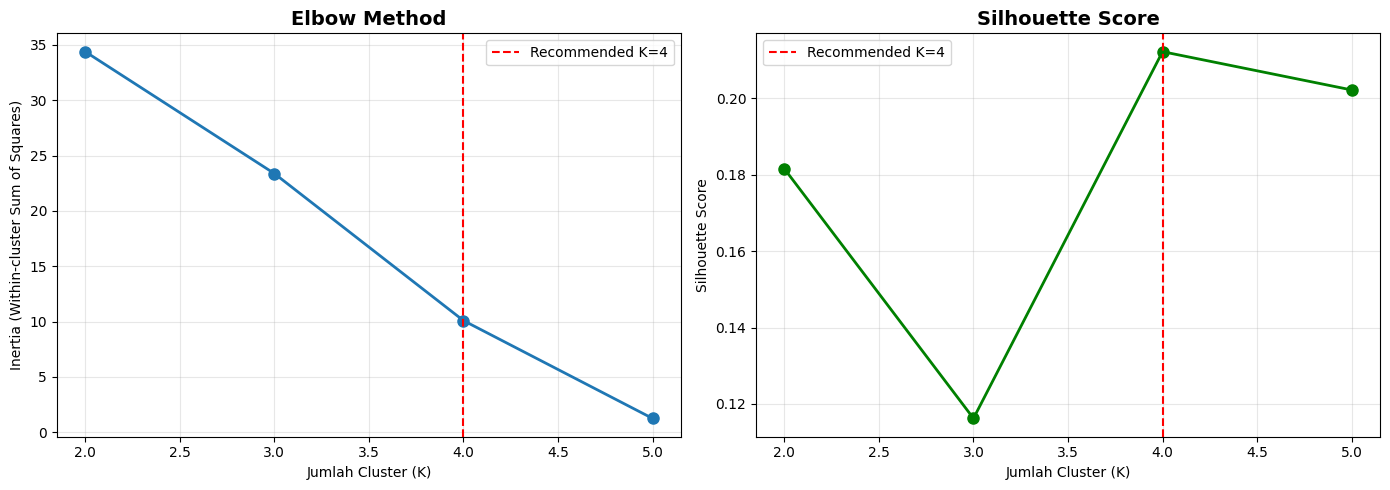

In [7]:
# Visualisasi: Elbow Method & Silhouette Score
if result_ai2["k_analysis"]:
    k_analysis = result_ai2["k_analysis"]
    k_values = list(k_analysis["inertia"].keys())
    inertia_values = list(k_analysis["inertia"].values())
    silhouette_values = [k_analysis["silhouette"][k] for k in k_values]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Elbow Method
    axes[0].plot(k_values, inertia_values, marker='o', linewidth=2, markersize=8)
    axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Jumlah Cluster (K)')
    axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)')
    axes[0].grid(alpha=0.3)
    if k_analysis["recommended_k"]:
        axes[0].axvline(x=k_analysis["recommended_k"], color='r', linestyle='--', 
                        label=f'Recommended K={k_analysis["recommended_k"]}')
        axes[0].legend()
    
    # Plot 2: Silhouette Score
    valid_sil = [s for s in silhouette_values if not np.isnan(s)]
    valid_k = [k for k, s in zip(k_values, silhouette_values) if not np.isnan(s)]
    
    axes[1].plot(valid_k, valid_sil, marker='o', linewidth=2, markersize=8, color='green')
    axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Jumlah Cluster (K)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].grid(alpha=0.3)
    if k_analysis["recommended_k"]:
        axes[1].axvline(x=k_analysis["recommended_k"], color='r', linestyle='--',
                        label=f'Recommended K={k_analysis["recommended_k"]}')
        axes[1].legend()
    
    plt.tight_layout()
    plt.show()


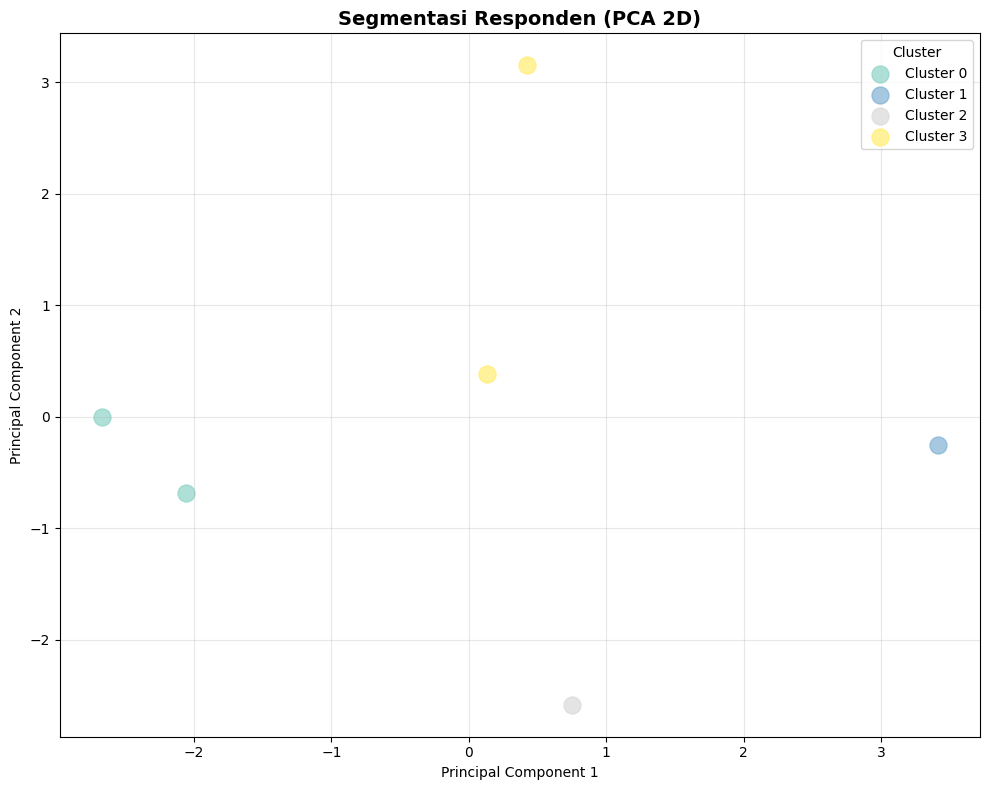

In [8]:
# Visualisasi: Scatter Plot PCA 2D dengan Cluster
pca_data = result_ai2["pca_2d"]
if pca_data:
    df_pca = pd.DataFrame(pca_data)
    
    # Plot scatter dengan warna berbeda per cluster
    unique_clusters = sorted(df_pca["cluster"].unique())
    colors = plt.cm.Set3(np.linspace(0, 1, len(unique_clusters)))
    
    plt.figure(figsize=(10, 8))
    for i, cluster in enumerate(unique_clusters):
        subset = df_pca[df_pca["cluster"] == cluster]
        plt.scatter(subset["x"], subset["y"], 
                   label=f'Cluster {cluster}', 
                   s=150, alpha=0.7, color=colors[i])
    
    plt.title('Segmentasi Responden (PCA 2D)', fontsize=14, fontweight='bold')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(title='Cluster')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


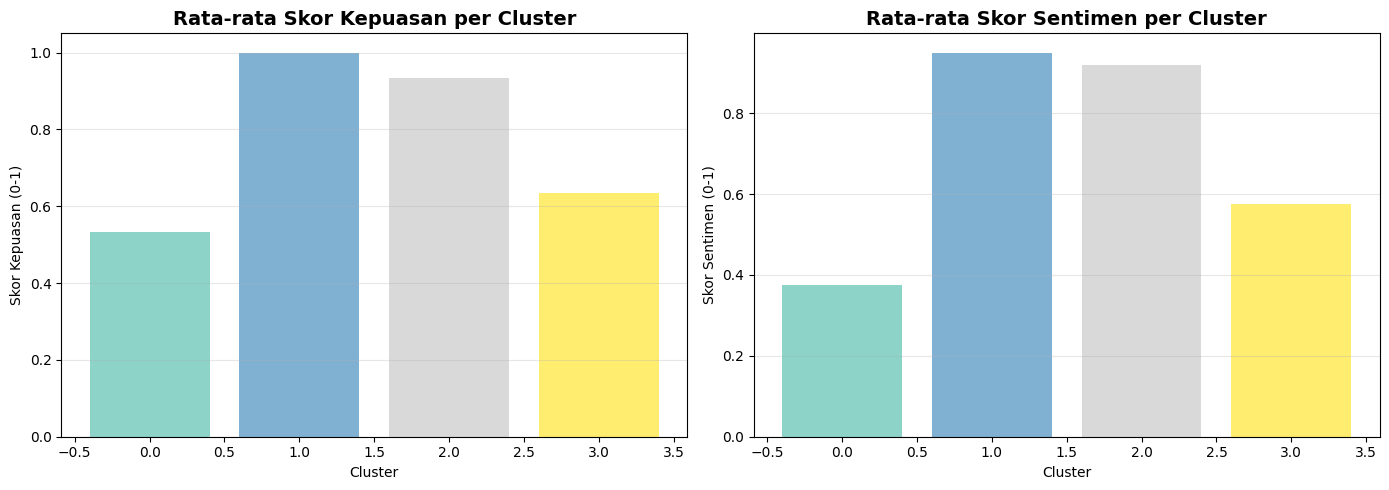

In [9]:
# Visualisasi: Perbandingan Skor Kepuasan & Sentimen per Cluster
clusters = result_ai2["clusters"]

df_cluster_analysis = pd.DataFrame({
    'cluster': clusters,
    'satisfaction': satisfaction_scores,
    'sentiment': sentiment_scores
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Rata-rata Skor Kepuasan per Cluster
cluster_satisfaction = df_cluster_analysis.groupby('cluster')['satisfaction'].mean()
axes[0].bar(cluster_satisfaction.index, cluster_satisfaction.values, 
           color=plt.cm.Set3(np.linspace(0, 1, len(cluster_satisfaction))))
axes[0].set_title('Rata-rata Skor Kepuasan per Cluster', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Skor Kepuasan (0-1)')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Rata-rata Skor Sentimen per Cluster
cluster_sentiment = df_cluster_analysis.groupby('cluster')['sentiment'].mean()
axes[1].bar(cluster_sentiment.index, cluster_sentiment.values,
           color=plt.cm.Set3(np.linspace(0, 1, len(cluster_sentiment))))
axes[1].set_title('Rata-rata Skor Sentimen per Cluster', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Skor Sentimen (0-1)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Export Hasil AI-2

Export hasil segmentasi untuk analisis lebih lanjut.


In [10]:
# Buat DataFrame lengkap dengan hasil AI-2
df_results = pd.DataFrame({
    'respondent_id': range(1, len(satisfaction_scores) + 1),
    'satisfaction_score': satisfaction_scores,
    'sentiment_score': sentiment_scores,
    'cluster': result_ai2["clusters"],
})

# Tambahkan informasi PCA
pca_data = result_ai2["pca_2d"]
if pca_data:
    df_pca = pd.DataFrame(pca_data)
    df_results['pca_x'] = df_pca['x']
    df_results['pca_y'] = df_pca['y']

print("=" * 60)
print("RINGKASAN HASIL AI-2")
print("=" * 60)
print("\n📊 DataFrame Hasil:")
print(df_results.head(10))

# Export ke CSV
output_file = 'segmentation_results.csv'
df_results.to_csv(output_file, index=False)
print(f"\n✅ Hasil diexport ke: {output_file}")

# Export detail ke JSON
output_json = {
    'k_used': result_ai2['k_used'],
    'clusters': result_ai2['clusters'],
    'k_analysis': result_ai2['k_analysis'],
    'preference_summary': result_ai2['preference_summary'],
    'pca_2d': result_ai2['pca_2d'],
}

json_file = 'segmentation_results.json'
with open(json_file, 'w', encoding='utf-8') as f:
    json.dump(output_json, f, indent=2, ensure_ascii=False)
print(f"✅ Hasil JSON diexport ke: {json_file}")


RINGKASAN HASIL AI-2

📊 DataFrame Hasil:
   respondent_id  satisfaction_score  sentiment_score  cluster     pca_x  \
0              1               0.933             0.92        2  0.750698   
1              2               0.600             0.65        3  0.426373   
2              3               0.400             0.30        0 -2.670591   
3              4               0.667             0.50        3  0.132875   
4              5               1.000             0.95        1  3.414018   
5              6               0.667             0.45        0 -2.053374   

      pca_y  
0 -2.584860  
1  3.150092  
2 -0.008467  
3  0.385105  
4 -0.257977  
5 -0.683894  

✅ Hasil diexport ke: segmentation_results.csv
✅ Hasil JSON diexport ke: segmentation_results.json
